In [1]:
import cartopy.crs as ccrs
import cartopy.feature
import matplotlib.pyplot as plt

import polars as pl

In [2]:
df = pl.read_parquet("Simulations/Simulation_Basin_2024-07_Eulerian.parquet")

/home/evansebill/Sargassum_growth_model/.pixi/envs/default/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/evansebill/Sargassum_growth_model/.pixi/envs/default/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/evansebill/Sargassum_growth_model/.pixi/envs/default/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/evansebill/Sargassum_growth_model/.pixi/envs/default/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  wa

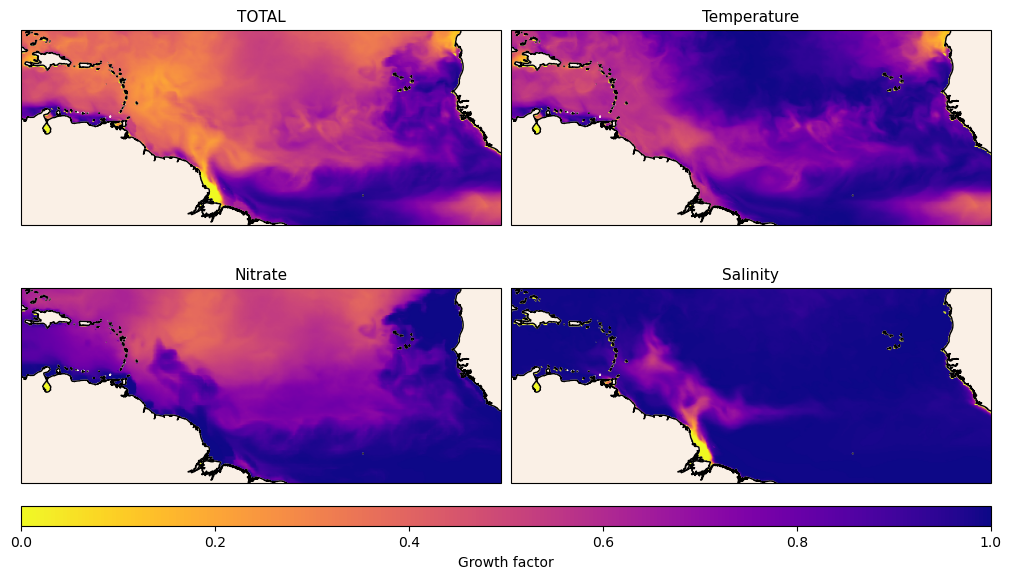

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(10,6), constrained_layout=True, subplot_kw={'projection': ccrs.PlateCarree()})

titles = ['TOTAL', 'Temperature', 'Nitrate', 'Salinity']
vars = ['limitation', 'lim_temp', 'lim_no3', 'lim_salinity']

for i, ax in enumerate(axes.flatten()):

    to_plot = (
        df.group_by('particle_id')
        .agg([
            pl.col('lon').first().alias('lon'),
            pl.col('lat').first().alias('lat'),
            pl.col(vars[i]).mean().alias('var_mean'),
        ])
        .sort('particle_id')
    )
    cscat = ax.scatter(
        to_plot['lon'], to_plot['lat'], c = to_plot['var_mean'],
        cmap='plasma_r', s=4, linewidth=0, transform=ccrs.PlateCarree(), zorder=2,
        vmin=0.0, vmax=1,
    )

    ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'), zorder=3, color='black')
    ax.add_feature(cartopy.feature.LAND.with_scale('10m'), zorder=2, color='linen')
    ax.set_extent([-75, -11, -3, 20])
    ax.set_title(titles[i], fontsize=11)

cbar = fig.colorbar(cscat, ax=axes, orientation='horizontal', pad=0.04, aspect=50, label='Growth factor')

plt.savefig("Figures/Figure6.png", bbox_inches="tight", dpi=300)
plt.show()